In [1]:
import pandas as pd
import numpy as np
file_path = r"C:\Users\Sukoon\OneDrive\Desktop\hist_data (1).xlsm"

In [3]:
sofr = pd.read_excel(file_path, sheet_name="SofrCurve", index_col=0).T
sofr.index = pd.to_datetime(sofr.index)

In [5]:
print(sofr.shape)

(251, 30)


In [7]:
# Compute daily absolute changes
sofr_changes = sofr.diff().dropna()

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA
pca = PCA()
pca.fit(sofr_changes)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(f"PC1: {explained[0]:.2%}")
print(f"PC2: {explained[1]:.2%}")
print(f"PC3: {explained[2]:.2%}")
print(f"Cumulative (3 PCs): {cumulative[2]:.2%}")

PC1: 70.63%
PC2: 14.69%
PC3: 10.64%
Cumulative (3 PCs): 95.96%


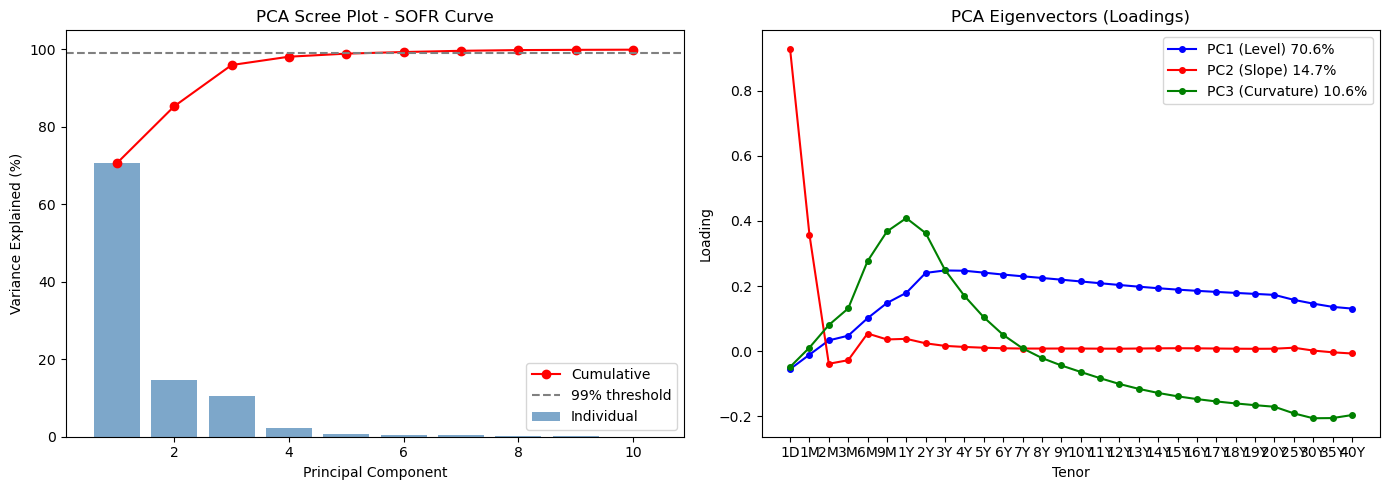

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scree plot
axes[0].bar(range(1, 11), explained[:10] * 100, color='steelblue', alpha=0.7, label='Individual')
axes[0].plot(range(1, 11), cumulative[:10] * 100, 'ro-', label='Cumulative')
axes[0].axhline(99, color='gray', linestyle='--', label='99% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('PCA Scree Plot - SOFR Curve')
axes[0].legend()

# Right: first 3 eigenvectors (loadings) — level, slope, curvature
tenors = sofr_changes.columns
axes[1].plot(tenors, pca.components_[0], 'b-o', markersize=4, label=f'PC1 (Level) {explained[0]:.1%}')
axes[1].plot(tenors, pca.components_[1], 'r-o', markersize=4, label=f'PC2 (Slope) {explained[1]:.1%}')
axes[1].plot(tenors, pca.components_[2], 'g-o', markersize=4, label=f'PC3 (Curvature) {explained[2]:.1%}')
axes[1].set_xlabel('Tenor')
axes[1].set_ylabel('Loading')
axes[1].set_title('PCA Eigenvectors (Loadings)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Extract 3 factor scores (time series of PC realizations)
pca3 = PCA(n_components=3)
factor_scores = pca3.fit_transform(sofr_changes)  # shape: (251, 3)
factor_scores_df = pd.DataFrame(
    factor_scores,
    index=sofr_changes.index,
    columns=['PC1_Level', 'PC2_Slope', 'PC3_Curvature']
)

In [11]:
print(factor_scores.shape)

(250, 3)


In [15]:
aapl =  pd.read_excel(file_path, sheet_name="AAPL", index_col=0)
msft =  pd.read_excel(file_path, sheet_name="MSFT", index_col=0)
f =  pd.read_excel(file_path, sheet_name="F", index_col=0)
bac =  pd.read_excel(file_path, sheet_name="BAC", index_col=0)

# Compute relative daily returns for stocks 
aapl_returns = aapl.pct_change().dropna()  
msft_returns = msft.pct_change().dropna()  
f_returns = f.pct_change().dropna()  
bac_returns = bac.pct_change().dropna()  

In [17]:
#align factor scores with stock returns 
pc_df = pd.DataFrame(
    factor_scores,
    index=aapl_returns.index,  
    columns=["PC1", "PC2", "PC3"]
)
pc_changes = pc_df.diff().dropna()

In [19]:
pc_df

,PC1,PC2,PC3
Date,,,
2022-11-01,-0.000491,0.000444,0.001590
2022-11-02,0.000435,0.000369,0.000469
2022-11-03,0.002650,0.000613,0.000867
2022-11-04,0.000073,0.006107,-0.001972
2022-11-07,0.002375,-0.006435,0.000173
...,...,...,...
2023-10-24,-0.000128,-0.000039,0.000881
2023-10-25,0.004650,-0.000014,-0.001983
2023-10-26,-0.004830,-0.000221,0.001000


In [21]:
# loading vectors 
loadings = pca3.components_.T

In [23]:
# average (baseline) sofr curve
curve_mean = sofr_changes.mean(axis=0).values

In [25]:
# factor scores on valuation date
current_scores = pc_df.loc["2023-10-30"].values

In [27]:
# reconstruct sofr curve c = c_hat + (loadings * scores)
def reconstruct_curve(curve_mean, loadings, scores):
    return curve_mean + loadings @ scores

In [29]:
#convert tenor to years 
def tenor_to_years(tenor):
    
    tenor = str(tenor)

    if tenor.endswith("D"):
        return float(tenor[:-1]) / 365
    if tenor.endswith("M"):
        return float(tenor[:-1]) / 12
    if tenor.endswith("Y"):
        return float(tenor[:-1])

tenor_years = np.array([tenor_to_years(t) for t in sofr_changes.columns])

In [31]:
#price of payer swap
def price_payer_swap(curve_rates, 
                     tenor_years, 
                     notional=100000000, 
                     fixed_rate=0.042, 
                     maturity=12):

    payment_times = np.arange(1, maturity + 1)

    # interpolate zero rates for payment times
    zero_rates = np.interp(payment_times, tenor_years, curve_rates)

    # discount factors
    dfs = np.exp(-zero_rates * payment_times)

    # fixed leg PV
    fixed_leg = notional * fixed_rate * np.sum(dfs)

    # floating leg PV
    float_leg = notional * (1 - dfs[-1])

    return float_leg - fixed_leg   

In [33]:
current_curve = reconstruct_curve(curve_mean, loadings, current_scores)
swap_pv = price_payer_swap(current_curve, tenor_years)
print("Current swap value:", swap_pv)

Current swap value: -50318994.59155213


In [35]:
#calculating sensitivities for change in PCs 
def compute_swap_pc_deltas(curve_mean, loadings, current_scores, tenor_years):

    x = 1.0
    n = len(current_scores)

    deltas = np.zeros(n)

    for i in range(n):

        scores_up = current_scores.copy()
        scores_dn = current_scores.copy()

        scores_up[i] += x
        scores_dn[i] -= x

        curve_up = reconstruct_curve(curve_mean, loadings, scores_up)
        curve_dn = reconstruct_curve(curve_mean, loadings, scores_dn)

        pv_up = price_payer_swap(curve_up, tenor_years)
        pv_dn = price_payer_swap(curve_dn, tenor_years)

        deltas[i] = (pv_up - pv_dn) / (2 * x)

    return deltas

In [37]:
swap_pc_deltas = compute_swap_pc_deltas(
    curve_mean,
    loadings,
    current_scores,
    tenor_years
)

print("Swap PC sensitivities:", swap_pc_deltas)

Swap PC sensitivities: [ 6.92202169e+08  1.21469457e+07 -1.53341670e+08]


In [39]:
stock_returns = pd.concat([
    aapl_returns,
    msft_returns,
    f_returns,
    bac_returns
], axis=1)

stock_returns.columns = ["AAPL","MSFT","F","BAC"]

In [41]:
risk_factors = pd.concat([stock_returns, pc_changes], axis=1).dropna()

In [43]:
print(risk_factors.shape)

(249, 7)


### Parametric VaR model 

$$
L = 1000000(R_{AAPL} + R_{MSFT} + R_F + R_{BAC}) 
+ \frac{\partial V}{\partial PC_1}\Delta PC_1 
+ \frac{\partial V}{\partial PC_2}\Delta PC_2 
+ \frac{\partial V}{\partial PC_3}\Delta PC_3
$$

In [46]:
# sensitivity vector 
stock_exposures = np.array([1000000,1000000,1000000,1000000])
w = np.concatenate([stock_exposures, swap_pc_deltas])

In [48]:
mu = risk_factors.mean()
sigma = risk_factors.cov()
mu = np.array([mu])
sigma = np.array([sigma])

In [50]:
L_mean = np.inner(w,mu)
L_var = np.dot(np.dot(sigma, w), np.transpose(w))

In [52]:
import statistics
import scipy.stats as stat

from statistics import NormalDist

In [54]:
VaR = abs(stat.norm.ppf(0.05, loc=L_mean, scale=np.sqrt(L_var)))
print("The 1 day 95% VaR using the parametric VaR model is equal to:", VaR)

The 1 day 95% VaR using the parametric VaR model is equal to: [5348778.49722949]


### Monte Carlo VaR

In [57]:
# risk-based change in value of portfolio 
def pnl_sensitivity(stock_returns, pc_factor_shocks):
    stock_pnl_r = 1e6 * np.sum(stock_returns)
    swap_pnl_r = np.dot(swap_pc_deltas, pc_factor_shocks)
    
    return stock_pnl_r + swap_pnl_r

In [59]:
# full revaluation change in value of portfolio 

def pnl_full(stock_returns, delta_curve):
    # Stocks: full revaluation = notional * ((1+r) - 1)
    stock_pnl_s = 1e6 * np.sum((1 + stock_returns) - 1)  
    # Swap: reprice under new curve = new_swap_value - current_swap_value
    new_curve = current_curve + delta_curve
    Ph = price_payer_swap(new_curve, tenor_years)
    swap_pnl_s = Ph - swap_pv
    
    return stock_pnl_s + swap_pnl_s

In [61]:
n = 100000

$$\Sigma = C \cdot C^T$$

$$\text{simulated} = Z \cdot C^T$$

In [63]:
#Cholesky decomposition to get correlated samples
cholesky = np.linalg.cholesky(sigma)       

In [65]:
#simulate independent standard normals
Z = np.random.standard_normal(size=(n, 7))  

In [67]:
# introduce correlation
simulated = Z @ cholesky.T             

In [69]:
simulated = np.squeeze(simulated)
simulated = simulated.T

In [71]:
simulated.shape

(100000, 7)

In [73]:
pnl_full_sample = []
pnl_sen_sample = []

for sim in simulated:
    stock_rets = sim[:4]              
    pc_shocks = sim[4:]               
    
    # reconstruct full curve shift from PC shocks
    delta_curve = pc_shocks @ pca3.components_  
    
    pnl_full_sample.append(pnl_full(stock_rets, delta_curve))
    pnl_sen_sample.append(pnl_sensitivity(stock_rets, pc_shocks))

pnl_full_sample = np.array(pnl_full_sample)
pnl_sen_sample = np.array(pnl_sen_sample)

In [74]:
VaR_full_mc = abs(np.percentile(pnl_full_sample, 5))
VaR_sen_mc  = abs(np.percentile(pnl_sen_sample, 5))

print("MC VaR 1d 95%, Full Revaluation:", VaR_full_mc)
print("MC VaR 1d 95%, Sensitivity-Based:", VaR_sen_mc)

MC VaR 1d 95%, Full Revaluation: 2423681.371090403
MC VaR 1d 95%, Sensitivity-Based: 5217605.156944909


##### MC full revaluation is lower as, the swap has positive convexity (given by PC2). When rates move a lot, the swap loses less than the linear approximation models predict.

### Historical VaR 

In [76]:
hist_pc_shocks   = risk_factors[['PC1','PC2','PC3']].to_numpy()
hist_stock_rets  = risk_factors[['AAPL','MSFT','F','BAC']].to_numpy()

hist_delta_curves = hist_pc_shocks @ pca3.components_

In [77]:
# risk-based valuation 
stock_pnl_hist    = 1e6 * hist_stock_rets.sum(axis=1)         
swap_pnl_sen_hist = hist_pc_shocks @ swap_pc_deltas 
pnl_sen_hist      = stock_pnl_hist + swap_pnl_sen_hist 

In [82]:
# full valuation of PnL
new_curves_hist = current_curve + hist_delta_curves  
swap_pnl_full = np.array([
    price_payer_swap(new_curves_hist[i], tenor_years) - swap_pv
    for i in range(len(risk_factors))
])                                                               
pnl_full_hist = stock_pnl_hist + swap_pnl_full             

In [84]:
VaR_sen_hist  = abs(np.percentile(pnl_sen_hist,  5))
VaR_full_hist = abs(np.percentile(pnl_full_hist, 5))

print("Historical VaR:")
print("1 day 95% VaR (Full Revaluation)",VaR_full_hist)
print("1 day 95% VaR (Risk Based)",VaR_sen_hist)

Historical VaR:
1 day 95% VaR (Full Revaluation) 2649516.362889386
1 day 95% VaR (Risk Based) 5517060.557618403


### Basel III backtesting

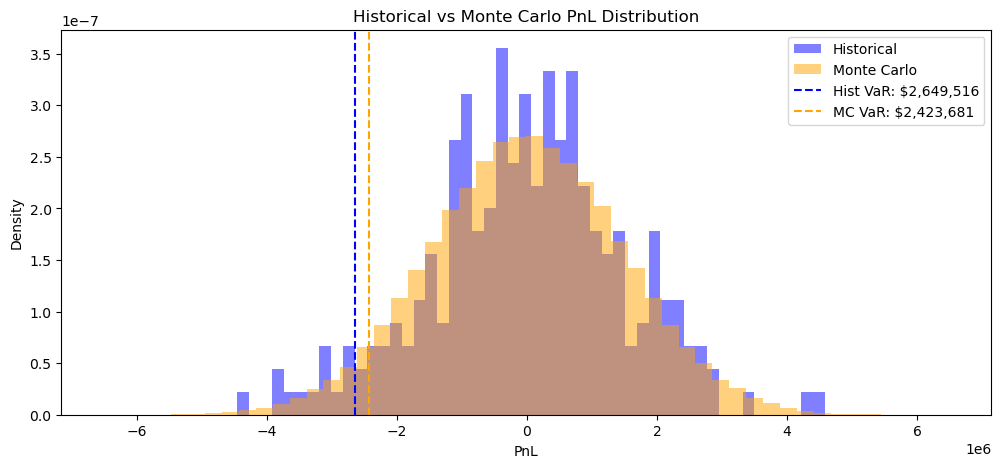

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.hist(pnl_full_hist, bins=50, alpha=0.5, color='blue', label='Historical', density=True)
plt.hist(pnl_full_sample, bins=50, alpha=0.5, color='orange', label='Monte Carlo', density=True)

plt.axvline(-VaR_full_hist, color='blue', linestyle='--', label=f'Hist VaR: ${VaR_full_hist:,.0f}')
plt.axvline(-VaR_full_mc, color='orange', linestyle='--', label=f'MC VaR: ${VaR_full_mc:,.0f}')

plt.xlabel('PnL')
plt.ylabel('Density')
plt.title('Historical vs Monte Carlo PnL Distribution')
plt.legend()
plt.show()

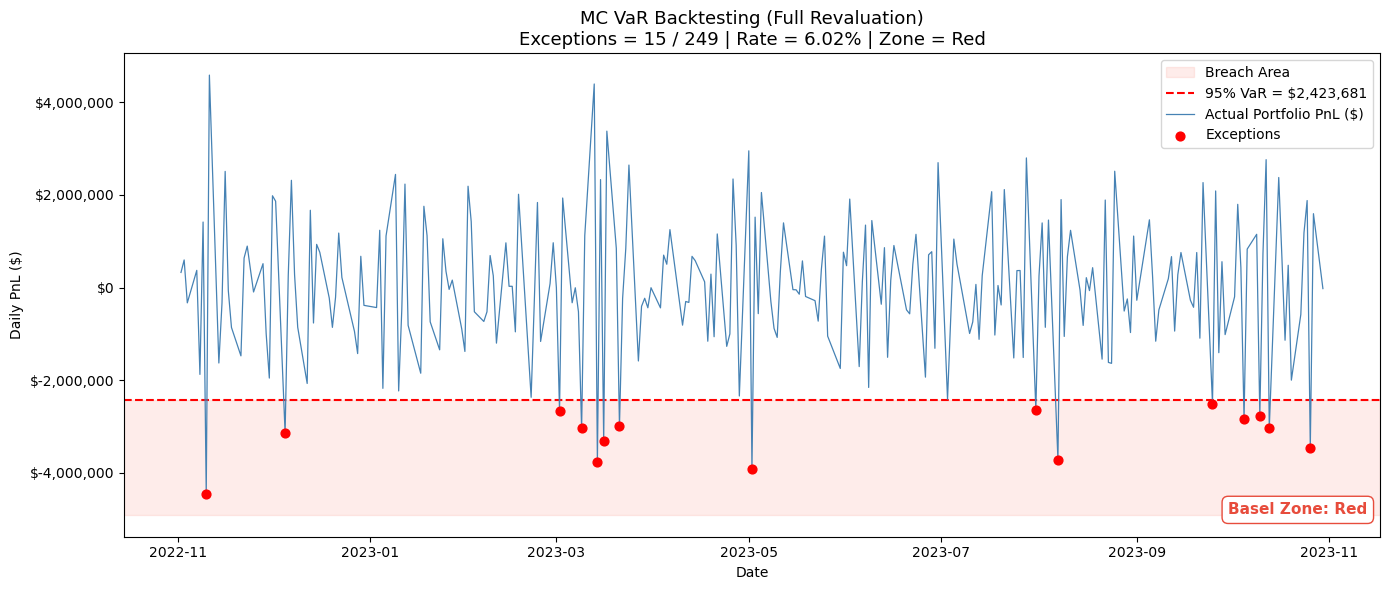

Exceptions : 15 / 249
Rate       : 6.02%


In [114]:
import matplotlib.pyplot as plt

# Basel thresholds
GREEN_MAX  = 4
YELLOW_MAX = 9

dates = risk_factors.index
n_days = len(pnl_full_hist)

var_threshold = -VaR_full_mc

# Exceptions 
exceptions_mask = pnl_full_hist < var_threshold
n_exceptions    = exceptions_mask.sum()
exception_rate  = n_exceptions / n_days * 100

# Basel Zone 
if n_exceptions <= GREEN_MAX:
    zone, zone_color = "Green", "#2ecc71"
elif n_exceptions <= YELLOW_MAX:
    zone, zone_color = "Yellow", "#f39c12"
else:
    zone, zone_color = "Red", "#e74c3c"

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Breach shading below VaR line
ax.axhspan(var_threshold, min(pnl_full_hist) * 1.1,
           color='salmon', alpha=0.15, label='Breach Area')

# VaR line
ax.axhline(var_threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'95% VaR = ${VaR_full_mc:,.0f}')

# Actual PnL line
ax.plot(dates, pnl_full_hist, color='steelblue', linewidth=0.9,
        label='Actual Portfolio PnL ($)')

# Exception dots
ax.scatter(dates[exceptions_mask], pnl_full_hist[exceptions_mask],
           color='red', zorder=5, s=40, label='Exceptions')

# Basel zone badge
badge_color = {'Green':'#2ecc71','Yellow':'#f39c12','Red':'#e74c3c'}[zone]
ax.text(0.99, 0.04, f'Basel Zone: {zone}',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=11, fontweight='bold', color=badge_color,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=badge_color))

# Labels
ax.set_title(
    f'MC VaR Backtesting (Full Revaluation)\n'
    f'Exceptions = {n_exceptions} / {n_days} | '
    f'Rate = {exception_rate:.2f}% | Zone = {zone}',
    fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Daily PnL ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Exceptions : {n_exceptions} / {n_days}")
print(f"Rate       : {exception_rate:.2f}%")